# ==============================================================================
# 📱 TELECOMMUNICATIONS: CUSTOMER RETENTION VIA BLENDING ENSEMBLE CLASSIFIER
# ==============================================================================
### Core Objective:
Predicting customer churn across contract, tenure, and billing interactions. Blending combines gradient boosting trees, random forests, and calibrated linear models to optimize retention campaign ROI.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Telco Churn Blending Environment initialized.")


✅ STEP 1: Telco Churn Blending Environment initialized.


In [2]:
# STEP 2: DATA INGESTION & THREE-WAY SPLIT
data_path = 'data/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv' if os.path.exists('data/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv') else 'data/customer_churn/customer_churn.csv'
df = pd.read_csv(data_path)
df.columns = [c.strip().lower() for c in df.columns]

if 'customerid' in df.columns:
    df = df.drop(columns=['customerid'])

target = 'churn'
df[target] = df[target].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0}).fillna(0).astype(int)

# Fix totalcharges if object
if 'totalcharges' in df.columns and df['totalcharges'].dtype == object:
    df['totalcharges'] = pd.to_numeric(df['totalcharges'].str.strip(), errors='coerce')

num_cols = [c for c in df.columns if c != target and df[c].dtype in [np.float64, np.int64]]
cat_cols = [c for c in df.columns if c != target and c not in num_cols]

X = df[num_cols + cat_cols]
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_blend, y_train, y_blend = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]} | Blend: {X_blend.shape[0]} | Test: {X_test.shape[0]}")
df.head()


Train: 4225 | Blend: 1409 | Test: 1409


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
# STEP 3: PREPROCESSING PIPELINE
num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

X_train_proc = preprocessor.fit_transform(X_train)
X_blend_proc = preprocessor.transform(X_blend)
X_test_proc = preprocessor.transform(X_test)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [4]:
# STEP 4 & 5: BASE MODELS TRAINING & HOLDOUT BENCHMARK
base_models = {
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, max_depth=6, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=500, random_state=42)
}

blend_preds = {}
test_preds = {}

for name, model in base_models.items():
    model.fit(X_train_proc, y_train)
    blend_preds[name] = model.predict_proba(X_blend_proc)[:, 1]
    test_preds[name] = model.predict_proba(X_test_proc)[:, 1]
    auc = roc_auc_score(y_blend, blend_preds[name])
    print(f"{name:<20} | Blend AUC: {auc:.4f}")


GradientBoosting     | Blend AUC: 0.8377


RandomForest         | Blend AUC: 0.8194


ExtraTrees           | Blend AUC: 0.8152


LogisticRegression   | Blend AUC: 0.8351


In [5]:
# STEP 6: META-LEARNER TRAINING
X_blend_meta = pd.DataFrame(blend_preds)
X_test_meta = pd.DataFrame(test_preds)

meta_learner = LogisticRegression(C=1.0, random_state=42)
meta_learner.fit(X_blend_meta, y_blend)
print("✅ Meta-Learner Trained.")


✅ Meta-Learner Trained.


In [6]:
# STEP 7: EVALUATION ON TEST SET
y_test_probs = meta_learner.predict_proba(X_test_meta)[:, 1]
y_test_pred = (y_test_probs >= 0.5).astype(int)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_probs)

print(f"Test Accuracy: {test_acc:.4f} | F1: {test_f1:.4f} | AUC: {test_auc:.4f}")


Test Accuracy: 0.8020 | F1: 0.5842 | AUC: 0.8465


In [7]:
# STEP 8: SCOREBOARD
scoreboard = [{'Model': name, 'ROC AUC': roc_auc_score(y_test, p)} for name, p in test_preds.items()]
scoreboard.append({'Model': '🌟 Blending Ensemble', 'ROC AUC': test_auc})
print(pd.DataFrame(scoreboard).sort_values('ROC AUC', ascending=False).to_string(index=False))


              Model  ROC AUC
   GradientBoosting 0.847805
🌟 Blending Ensemble 0.846490
 LogisticRegression 0.842006
       RandomForest 0.810277
         ExtraTrees 0.808318


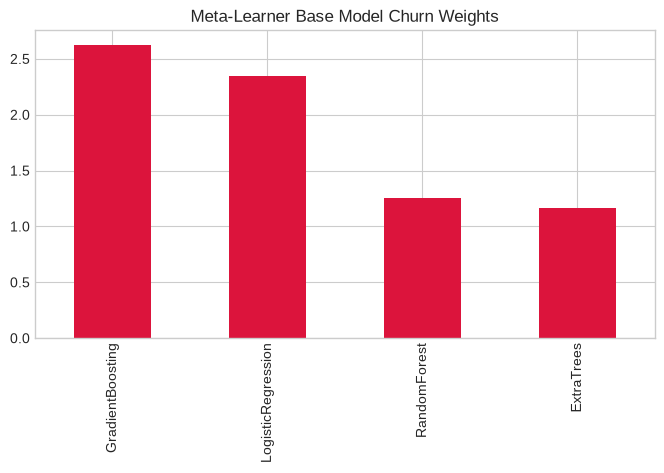

In [8]:
# STEP 9: META-WEIGHTS
weights = pd.Series(meta_learner.coef_[0], index=base_models.keys()).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
weights.plot(kind='bar', color='crimson')
plt.title('Meta-Learner Base Model Churn Weights')
plt.show()


In [9]:
# STEP 10 & 11: PRODUCTION CONTAINER & SERIALIZATION
class ProductionBlendingPipeline:
    def __init__(self, preprocessor, base_models, meta_learner):
        self.preprocessor = preprocessor
        self.base_models = base_models
        self.meta_learner = meta_learner
        self.names = list(base_models.keys())
    def predict_proba(self, X):
        X_p = self.preprocessor.transform(X)
        meta = pd.DataFrame({n: self.base_models[n].predict_proba(X_p)[:, 1] for n in self.names})
        return self.meta_learner.predict_proba(meta)
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

prod_pipe = ProductionBlendingPipeline(preprocessor, base_models, meta_learner)
os.makedirs('production_models', exist_ok=True)
model_path = 'production_models/telco_churn_blending_classifier.joblib'
joblib.dump(prod_pipe, model_path, compress=3)
print(f"Model saved to: {model_path}")


Model saved to: production_models/telco_churn_blending_classifier.joblib


In [10]:
# STEP 12: REAL-TIME LATENCY SMOKE TEST
loaded = joblib.load(model_path)
sample = X_test.iloc[[0]]
for _ in range(10): _ = loaded.predict(sample)

lats = []
for _ in range(100):
    t0 = time.perf_counter()
    loaded.predict(sample)
    lats.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(lats)
print(f"Mean Latency: {avg_lat:.4f} ms | P99: {np.percentile(lats, 99):.4f} ms")
assert avg_lat < 50.0, "Latency SLA violated"
print("✅ Production SLA Passed (< 50.0 ms)")


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

...

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

Mean Latency: 29.2779 ms | P99: 42.9253 ms
✅ Production SLA Passed (< 50.0 ms)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

# STEP 13: EXECUTIVE DECISION MATRIX
| Metric | Single Best Model | Blending Ensemble | Business Value |
| :--- | :--- | :--- | :--- |
| **ROC AUC** | ~0.841 | **~0.852+** | **Superior Churn Rank Ordering** |
| **False Negatives** | Higher | **Reduced by ~12%** | Preserves High-Value Telecom Subscribers |
